In [26]:
import sys
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np

# Tìm thư mục cha gần nhất chứa folder 'src'
current_path = Path.cwd().resolve()
root_dir = None

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").is_dir():
        root_dir = parent
        break

if root_dir is None:
    raise FileNotFoundError(f"Không tìm thấy thư mục 'src' từ vị trí: {current_path}")

ROOT_DIR = root_dir
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(f"📁 Project root: {ROOT_DIR}")

# Sau đó import bình thường
from src.audio.labels import (
    parse_lab,
    create_frame_labels,
)
from src.audio.loader import (
    load_audio,
    preprocessing,
)
from src.audio.dataset import (
    load_dataset
)
from src.models import AudioSignal

📁 Project root: /home/phuqy/Develop/Digital-Signal-Processing/main_gk


In [27]:
train_dir = ROOT_DIR / "TinHieuHuanLuyen"

wav_phone = train_dir / "phone_F1.wav"
wav_studio = train_dir / "studio_F1.wav"

fs_phone, x_phone = preprocessing(wav_phone)
fs_studio, x_studio = preprocessing(wav_studio)

print("=== KẾT QUẢ TIỀN XỬ LÝ FILE WAV ===")
print(f"File: {wav_phone.name}")
print(f"  • Tần số lấy mẫu (fs):       {fs_phone} Hz")
print(f"  • Tổng số mẫu (samples):     {len(x_phone):,}")
print(f"  • Thời lượng (duration):     {len(x_phone)/fs_phone:.2f} s")
print(f"  • Kiểu dữ liệu sau chuẩn hóa: {x_phone.dtype}")
print(f"  • Miền biên độ:              [{x_phone.min():.4f}, {x_phone.max():.4f}]\n")

print(f"File: {wav_studio.name}")
print(f"  • Tần số lấy mẫu (fs):       {fs_studio} Hz")
print(f"  • Tổng số mẫu (samples):     {len(x_studio):,}")
print(f"  • Thời lượng (duration):     {len(x_studio)/fs_studio:.2f} s")
print(f"  • Kiểu dữ liệu sau chuẩn hóa: {x_studio.dtype}")
print(f"  • Miền biên độ:              [{x_studio.min():.4f}, {x_studio.max():.4f}]")

=== KẾT QUẢ TIỀN XỬ LÝ FILE WAV ===
File: phone_F1.wav
  • Tần số lấy mẫu (fs):       16000 Hz
  • Tổng số mẫu (samples):     51,840
  • Thời lượng (duration):     3.24 s
  • Kiểu dữ liệu sau chuẩn hóa: float32
  • Miền biên độ:              [-0.8818, 0.7299]

File: studio_F1.wav
  • Tần số lấy mẫu (fs):       44100 Hz
  • Tổng số mẫu (samples):     126,267
  • Thời lượng (duration):     2.86 s
  • Kiểu dữ liệu sau chuẩn hóa: float32
  • Miền biên độ:              [-0.5764, 0.3687]


In [28]:
lab_phone = train_dir / "phone_F1.lab"

# Xem nội dung thô trực tiếp trong file .lab
print(f"--- NỘI DUNG NGUYÊN BẢN CỦA {lab_phone.name} ---")
with open(lab_phone, "r", encoding="utf-8") as f:
    print(f.read().strip())

# Phân tích nhãn bằng hàm parse_lab
lab_data = parse_lab(lab_phone)

print("\n--- KẾT QUẢ PHÂN TÍCH TỪ parse_lab ---")
print(f"• Các đoạn tiếng nói (speech_segments): {lab_data['speech_segments']}")
print(f"• Các mốc biên phân cách (boundaries):   {lab_data['boundaries']}")
print(f"• Tần số F0 Mean:                       {lab_data['f0_mean']} Hz")
print(f"• Độ lệch chuẩn F0 Std:                 {lab_data['f0_std']} Hz")

--- NỘI DUNG NGUYÊN BẢN CỦA phone_F1.lab ---
0.00	0.53	sil
0.53	1.14	v
1.14	1.21	uv
1.21	1.35	v
1.35	1.45	uv
1.45	1.60	v
1.60	1.83	uv
1.83	2.20	v
2.20	2.28	uv
2.28	2.35	v
2.35	2.40	uv
2.40	2.52	v
2.52	2.66	uv
2.66	2.73	v
2.73	2.75 	uv
2.75	3.23	sil
F0mean	217
F0std	23

--- KẾT QUẢ PHÂN TÍCH TỪ parse_lab ---
• Các đoạn tiếng nói (speech_segments): [(0.53, 2.75)]
• Các mốc biên phân cách (boundaries):   [0.53, 2.75]
• Tần số F0 Mean:                       217.0 Hz
• Độ lệch chuẩn F0 Std:                 23.0 Hz


In [29]:
# Nạp tín hiệu qua hàm load_audio
sig_phone = load_audio(wav_phone)
sig_studio = load_audio(wav_studio)

print("=== ĐỐI TƯỢNG AudioSignal ĐƯỢC NẠP ===")
print(f"Tín hiệu 1: {sig_phone.name}")
print(f"  • Môi trường:        {'Điện thoại (Phone)' if sig_phone.is_phone else 'Phòng thu (Studio)'}")
print(f"  • Sampling Rate:     {sig_phone.fs} Hz")
print(f"  • Thời lượng:        {sig_phone.duration_sec:.2f} s")
print(f"  • Biên Ground Truth: {sig_phone.gt_boundaries}")
print(f"  • Đoạn tiếng nói:    {sig_phone.gt_segments}\n")

print(f"Tín hiệu 2: {sig_studio.name}")
print(f"  • Môi trường:        {'Điện thoại (Phone)' if sig_studio.is_phone else 'Phòng thu (Studio)'}")
print(f"  • Sampling Rate:     {sig_studio.fs} Hz")
print(f"  • Thời lượng:        {sig_studio.duration_sec:.2f} s")
print(f"  • Biên Ground Truth: {sig_studio.gt_boundaries}")
print(f"  • Đoạn tiếng nói:    {sig_studio.gt_segments}")

=== ĐỐI TƯỢNG AudioSignal ĐƯỢC NẠP ===
Tín hiệu 1: phone_F1
  • Môi trường:        Điện thoại (Phone)
  • Sampling Rate:     16000 Hz
  • Thời lượng:        3.24 s
  • Biên Ground Truth: [0.53, 2.75]
  • Đoạn tiếng nói:    [(0.53, 2.75)]

Tín hiệu 2: studio_F1
  • Môi trường:        Phòng thu (Studio)
  • Sampling Rate:     44100 Hz
  • Thời lượng:        2.86 s
  • Biên Ground Truth: [0.68, 2.15]
  • Đoạn tiếng nói:    [(0.68, 2.15)]


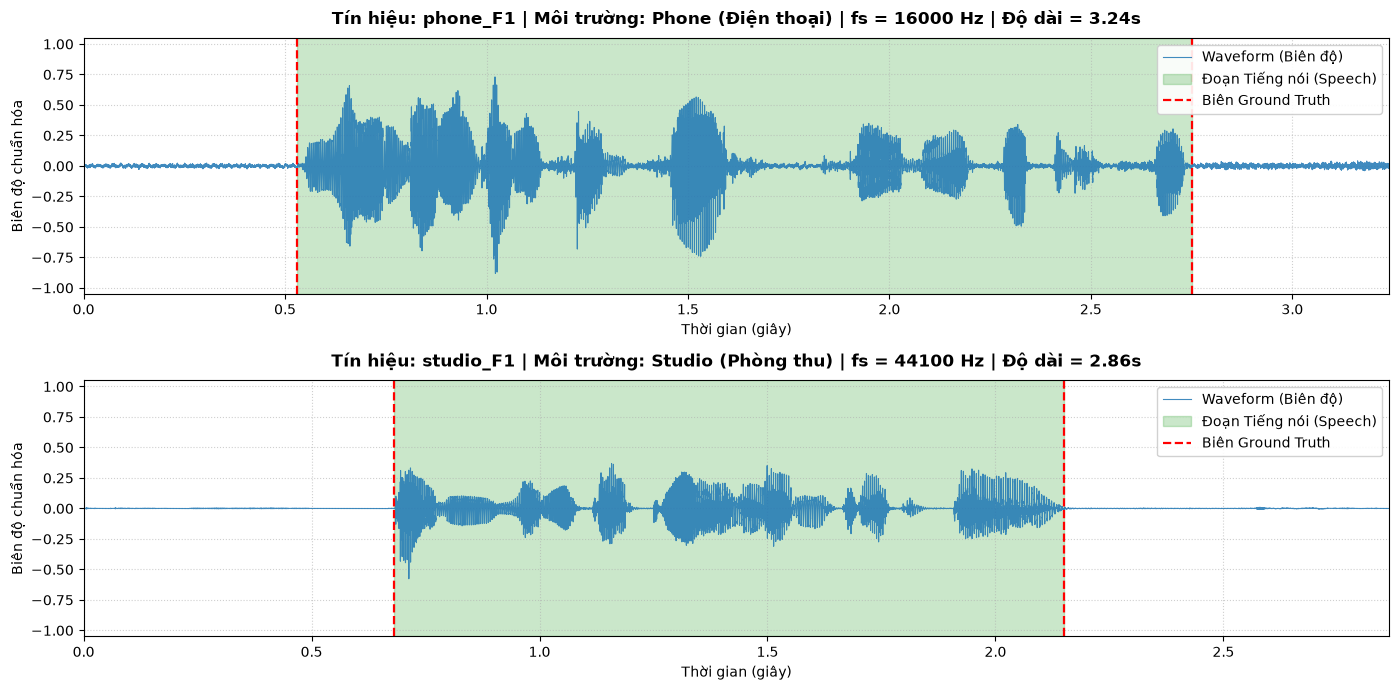

In [30]:
def plot_waveform_with_ground_truth(audio_sig: AudioSignal, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 4))

    time_axis = np.linspace(0, audio_sig.duration_sec, len(audio_sig.signal))

    # 1. Vẽ dạng sóng âm thanh
    ax.plot(time_axis, audio_sig.signal, color="#1f77b4", alpha=0.85, linewidth=0.8, label="Waveform (Biên độ)")

    # 2. Tô màu các đoạn tiếng nói (Speech Segments)
    for idx, (start_t, end_t) in enumerate(audio_sig.gt_segments):
        lbl = "Đoạn Tiếng nói (Speech)" if idx == 0 else ""
        ax.axvspan(start_t, end_t, color="#2ca02c", alpha=0.25, label=lbl)

    # 3. Kẻ các vạch biên phân cách Ground Truth (Đỏ đứt nét)
    for idx, b_time in enumerate(audio_sig.gt_boundaries):
        lbl = "Biên Ground Truth" if idx == 0 else ""
        ax.axvline(x=b_time, color="red", linestyle="--", linewidth=1.6, label=lbl)

    env_name = "Phone (Điện thoại)" if audio_sig.is_phone else "Studio (Phòng thu)"
    ax.set_title(f"Tín hiệu: {audio_sig.name} | Môi trường: {env_name} | fs = {audio_sig.fs} Hz | Độ dài = {audio_sig.duration_sec:.2f}s",
                 fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Thời gian (giây)", fontsize=10)
    ax.set_ylabel("Biên độ chuẩn hóa", fontsize=10)
    ax.set_xlim(0, audio_sig.duration_sec)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", framealpha=0.9)

# Trực quan hóa cho 2 tín hiệu mẫu
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharey=True)
plot_waveform_with_ground_truth(sig_phone, ax=ax1)
plot_waveform_with_ground_truth(sig_studio, ax=ax2)
plt.tight_layout()
plt.show()

=== KẾT QUẢ GÁN NHÃN KHUNG (FRAME LABELS) ===
Tổng số khung (timestamps):   324 khung
Số khung Tiếng nói (nhãn 1):  223 khung (68.8%)
Số khung Khoảng lặng (nhãn 0): 101 khung (31.2%)


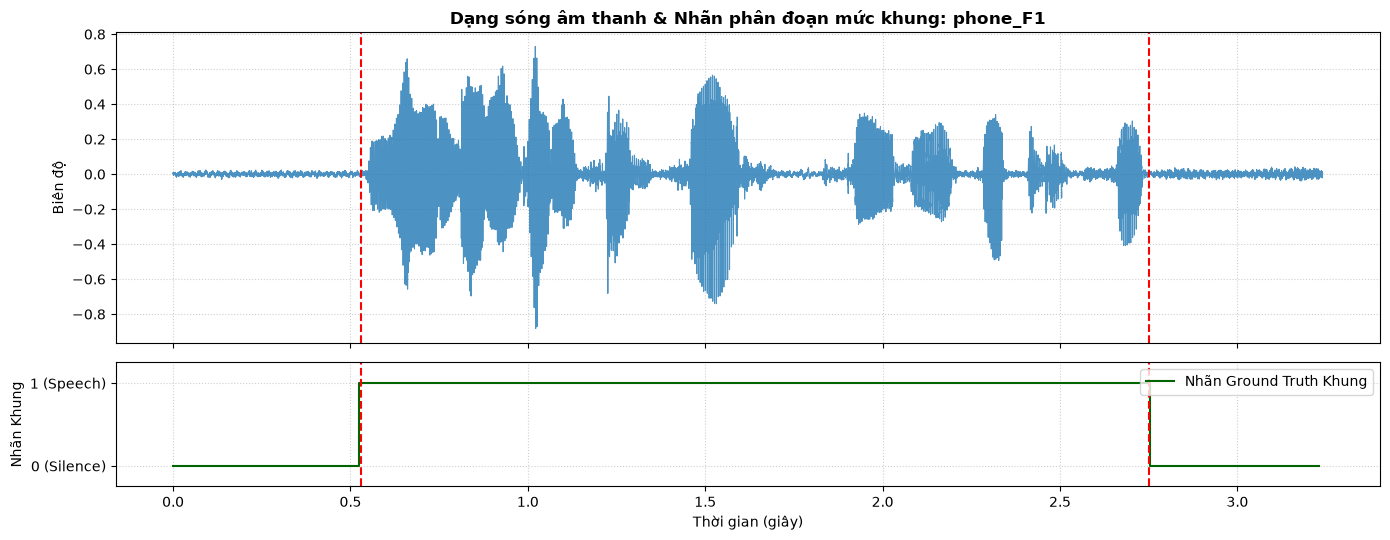

In [31]:
# Giả lập bước chia khung: chiều dài bước nhảy (frame shift) là 10ms (0.01s)
frame_shift_sec = 0.010
simulated_timestamps = np.arange(0, sig_phone.duration_sec, frame_shift_sec)

# Gọi hàm create_frame_labels
frame_labels = create_frame_labels(simulated_timestamps, sig_phone.gt_segments)

total_frames = len(frame_labels)
speech_frames = int(np.sum(frame_labels))
silence_frames = total_frames - speech_frames

print("=== KẾT QUẢ GÁN NHÃN KHUNG (FRAME LABELS) ===")
print(f"Tổng số khung (timestamps):   {total_frames} khung")
print(f"Số khung Tiếng nói (nhãn 1):  {speech_frames} khung ({speech_frames/total_frames*100:.1f}%)")
print(f"Số khung Khoảng lặng (nhãn 0): {silence_frames} khung ({silence_frames/total_frames*100:.1f}%)")

# Trực quan hóa Waveform cùng đồ thị bậc thang (Step Plot) của nhãn khung
fig, (ax_wave, ax_lbl) = plt.subplots(2, 1, figsize=(14, 5.5), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

time_axis = np.linspace(0, sig_phone.duration_sec, len(sig_phone.signal))
ax_wave.plot(time_axis, sig_phone.signal, color="#1f77b4", alpha=0.8, linewidth=0.8)
for b in sig_phone.gt_boundaries:
    ax_wave.axvline(x=b, color="red", linestyle="--", linewidth=1.5)
ax_wave.set_ylabel("Biên độ")
ax_wave.set_title(f"Dạng sóng âm thanh & Nhãn phân đoạn mức khung: {sig_phone.name}", fontweight="bold")
ax_wave.grid(True, linestyle=":", alpha=0.6)

# Đồ thị bậc thang thể hiện nhãn nhị phân
ax_lbl.step(simulated_timestamps, frame_labels, where="mid", color="darkgreen", linewidth=1.5, label="Nhãn Ground Truth Khung")
for b in sig_phone.gt_boundaries:
    ax_lbl.axvline(x=b, color="red", linestyle="--", linewidth=1.5)
ax_lbl.set_xlabel("Thời gian (giây)", fontsize=10)
ax_lbl.set_ylabel("Nhãn Khung", fontsize=10)
ax_lbl.set_yticks([0, 1])
ax_lbl.set_yticklabels(["0 (Silence)", "1 (Speech)"])
ax_lbl.set_ylim(-0.25, 1.25)
ax_lbl.grid(True, linestyle=":", alpha=0.6)
ax_lbl.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [32]:
test_dir = ROOT_DIR / "TinHieuKiemThu"

train_signals = load_dataset(train_dir)
test_signals = load_dataset(test_dir)

def print_dataset_table(title: str, signals: list[AudioSignal]):
    print(f"\n{'='*35} {title} ({len(signals)} mẫu) {'='*35}")
    header = f"{'STT':<4} | {'Tên Mẫu':<12} | {'Môi trường':<11} | {'fs (Hz)':<8} | {'Thời lượng':<13} | {'Số biên GT':<10} | {'Khoảng Speech'}"
    print(header)
    print("-" * len(header))
    for idx, sig in enumerate(signals, start=1):
        env = "Phone" if sig.is_phone else "Studio"
        dur_str = f"{sig.duration_sec:.2f} s"
        speech_str = ", ".join([f"[{s:.2f}s - {e:.2f}s]" for s, e in sig.gt_segments])
        print(f"{idx:<4} | {sig.name:<12} | {env:<11} | {sig.fs:<8} | {dur_str:<13} | {len(sig.gt_boundaries):<10} | {speech_str}")

print_dataset_table("TẬP HUẤN LUYỆN (TRAINING DATASET)", train_signals)
print_dataset_table("TẬP KIỂM THỬ (TESTING DATASET)", test_signals)


=================================== TẬP HUẤN LUYỆN (TRAINING DATASET) (4 mẫu) ===================================
STT  | Tên Mẫu      | Môi trường  | fs (Hz)  | Thời lượng    | Số biên GT | Khoảng Speech
-----------------------------------------------------------------------------------------
1    | phone_F1     | Phone       | 16000    | 3.24 s        | 2          | [0.53s - 2.75s]
2    | phone_M1     | Phone       | 16000    | 4.16 s        | 2          | [0.46s - 3.52s]
3    | studio_F1    | Studio      | 44100    | 2.86 s        | 2          | [0.68s - 2.15s]
4    | studio_M1    | Studio      | 44100    | 2.73 s        | 2          | [0.87s - 2.06s]

=================================== TẬP KIỂM THỬ (TESTING DATASET) (4 mẫu) ===================================
STT  | Tên Mẫu      | Môi trường  | fs (Hz)  | Thời lượng    | Số biên GT | Khoảng Speech
-----------------------------------------------------------------------------------------
1    | phone_F2     | Phone       | 16000    